In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mysql.connector
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings("ignore")

In [2]:
# loading the dataset
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="suyog123poudel",
    database="company_db"
)

In [3]:

df = pd.read_sql_query("Select * from vendor_sales_summary",connection)
df

,VendorNumber,VendorName,Brand,Volume,Description,ActualPrice,PurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollar,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,ExciseTax,TotalFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,105,ALTAMAR BRANDS LLC,8412,750,Tequila Ocho Plata Fresno,49.99,35.71,320,11427.20,307,15346.93,12947.41,242.0,62.39,3919.73,25.540808,0.959375,1.343018
1,4466,AMERICAN VINTAGE BEVERAGE,5255,1750,TGI Fridays Ultimte Mudslide,12.99,9.35,6215,58110.25,6096,79187.04,51180.60,11204.0,793.91,21076.79,26.616464,0.980853,1.362703
2,4466,AMERICAN VINTAGE BEVERAGE,5215,1750,TGI Fridays Long Island Iced,12.99,9.41,4923,46325.43,4651,60416.49,41542.02,8549.0,793.91,14091.06,23.323202,0.944749,1.304175
3,480,BACARDI USA INC,3348,1750,Bombay Sapphire Gin,29.99,22.38,57349,1283470.62,56888,1766391.12,460087.95,104525.0,89286.27,482920.50,27.339387,0.991961,1.376261
4,480,BACARDI USA INC,8358,750,Bacardi 151 Proof,19.99,14.49,7071,102458.79,8065,161219.35,87396.28,6353.0,89286.27,58760.56,36.447585,1.140574,1.573504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10688,4425,MARTIGNETTI COMPANIES,28007,750,Priest Ranch Sauvignon Blanc,18.99,12.41,120,1489.20,0,0.00,0.00,0.0,144929.24,-1489.20,0.000000,0.000000,0.000000
10689,7153,PINE STATE TRADING CO,26508,750,Ch Maycott Red,10.49,6.81,1,6.81,1,10.49,10.49,0.0,15884.82,3.68,35.081030,1.000000,1.540382
10690,8004,SAZERAC CO INC,2936,750,Abraham Bowman Ltd Edition,69.99,53.02,18,954.36,4,279.96,69.99,3.0,50293.62,-674.40,-240.891556,0.222222,0.293348
10691,2000,SOUTHERN WINE & SPIRITS NE,26266,750,The Divining Rod Pinot Noir,16.99,11.56,132,1525.92,2,33.98,16.99,0.0,19016.59,-1491.94,-4390.641554,0.015152,0.022269


# EDA
- Previously we understand the relationship between the table and its variables
- In this phase of EDA we analysis the distribution and gain insights of each column for the data set

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10693.0,10649.892921,18752.805318,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10693.0,18037.744319,12662.525384,58.000000,5789.000000,18761.000000,25514.000000,9.063100e+04
Volume,10693.0,847.351351,664.278909,50.000000,750.000000,750.000000,750.000000,2.000000e+04
ActualPrice,10693.0,35.640338,148.239484,0.000000,10.990000,15.990000,28.990000,7.499990e+03
PurchasePrice,10693.0,24.383023,109.264519,0.000000,6.840000,10.450000,19.470000,5.681810e+03
TotalPurchaseQuantity,10693.0,3140.781539,11094.573249,1.000000,36.000000,262.000000,1978.000000,3.376600e+05
TotalPurchaseDollar,10693.0,30103.877820,123062.388765,0.000000,453.180000,3655.230000,20733.420000,3.811252e+06
TotalSalesQuantity,10693.0,3077.356308,10952.346909,0.000000,33.000000,261.000000,1929.000000,3.349390e+05
TotalSalesDollars,10693.0,42244.312108,167648.300465,0.000000,729.270000,5298.210000,28406.050000,5.101920e+06
TotalSalesPrice,10693.0,18797.686610,44952.483000,0.000000,289.710000,2857.800000,16075.380000,6.728193e+05


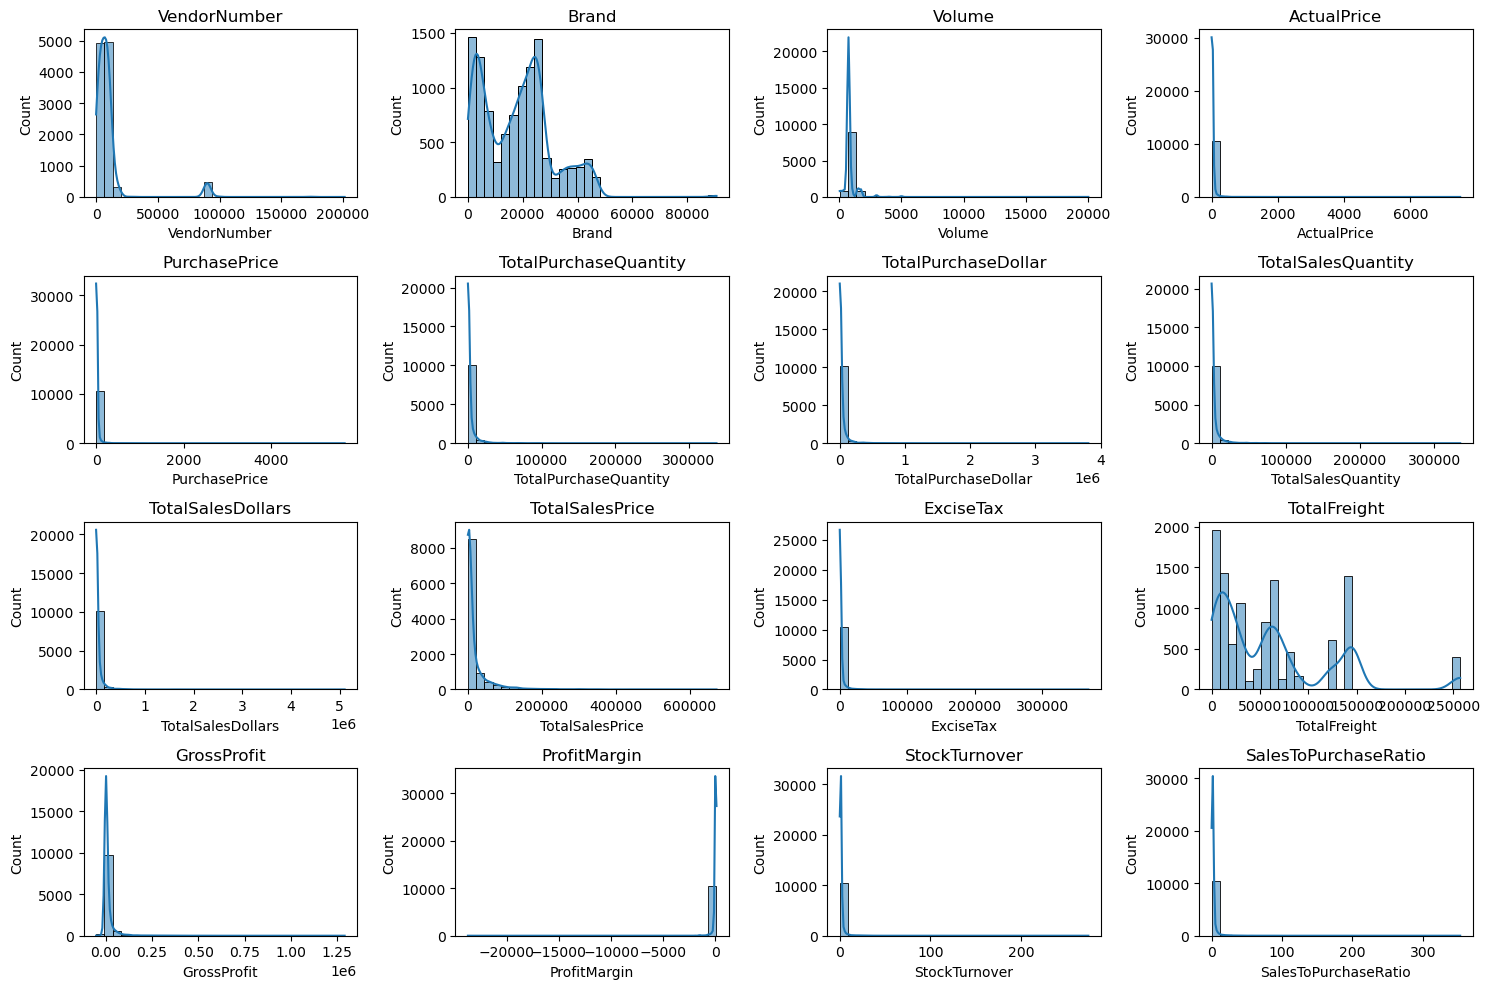

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
    plt.tight_layout()

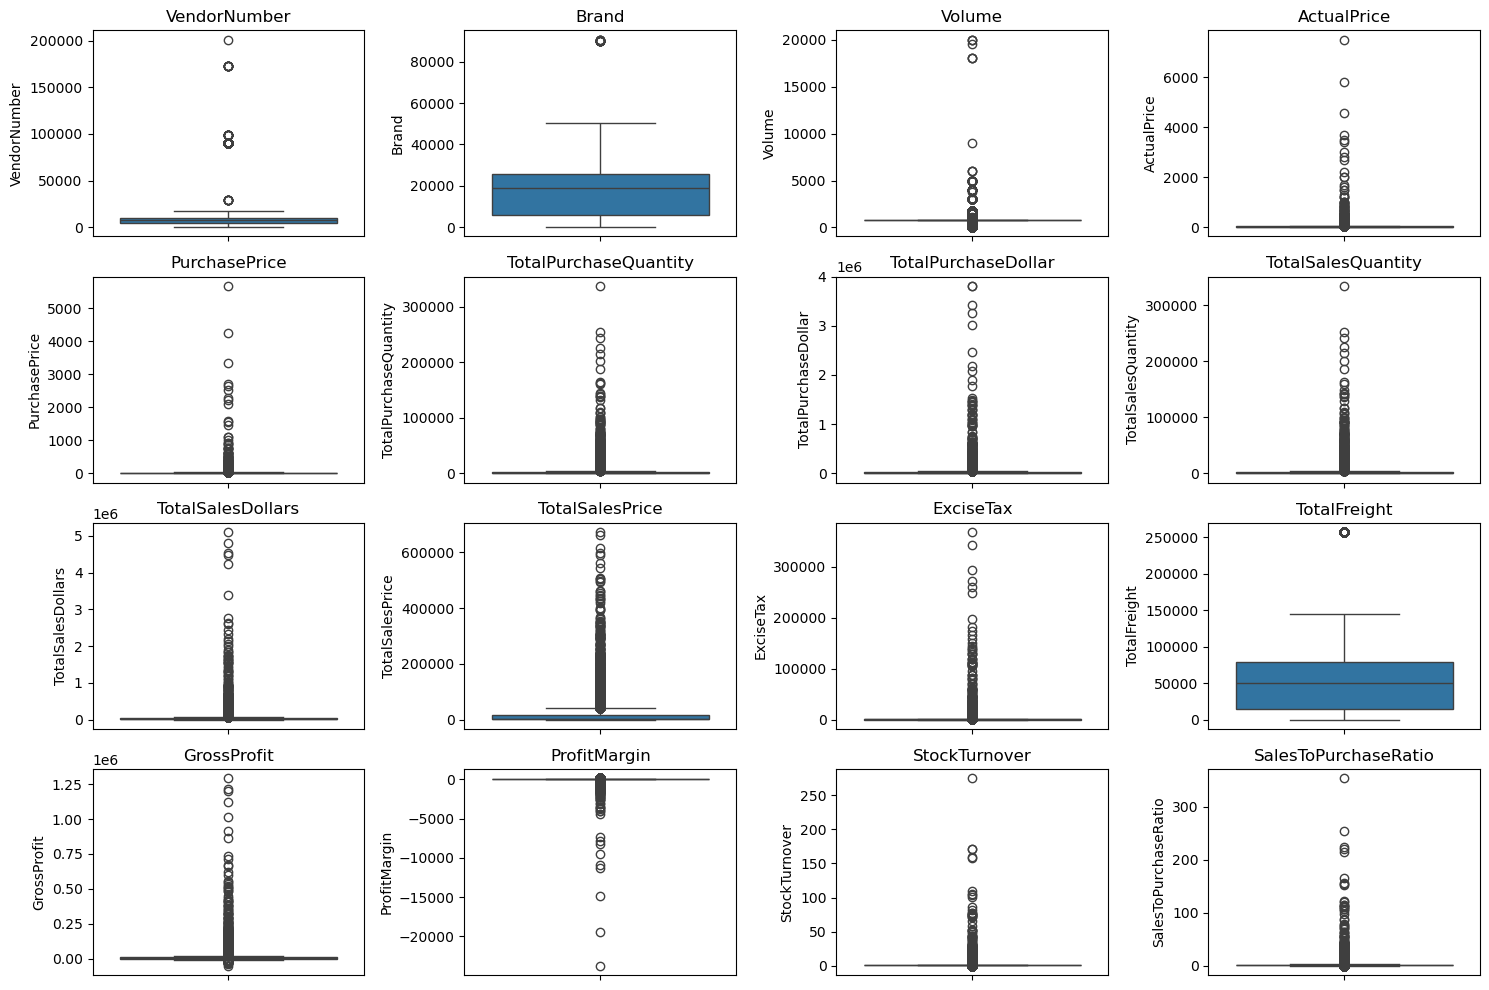

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    plt.title(col)
    plt.tight_layout()

# Insights
- Most of the products/orders are sold very little and rest of the products make huge money (Business depend on fewer star product)
- Profit margin is mostly concentrated at 0 meaning only some star products make profit rest are at neutral or making loss
- Most of the product are not selling (dead stock) only fewer products are sold faster

<Axes: xlabel='TotalPurchaseQuantity', ylabel='TotalFreight'>

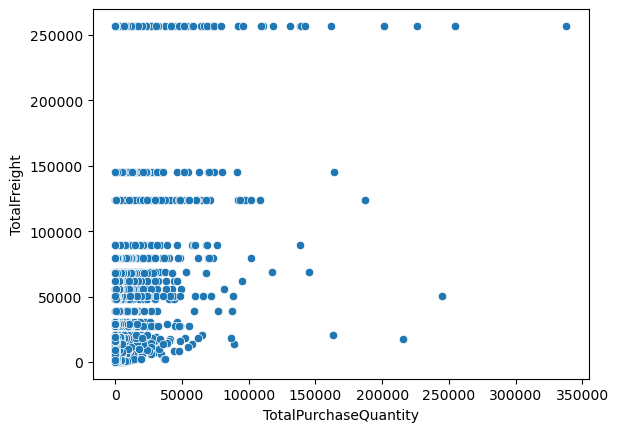

In [7]:
sns.scatterplot(data=df,y="TotalFreight",x="TotalPurchaseQuantity")

# Insights
- The scatter plot shows that low purchase quantities are associated with high freight costs per unit, while higher purchase quantities are more cost-efficient.
- This means the company often places small orders, which increases shipping cost per item.
  As a result, freight cost becomes a major reason for low profit or even losses, especially for small-volume purchases.
- The main issue is inefficient purchasing behavior:
buying in small quantities repeatedly instead of bulk purchasing increases logistics cost significantly.

In [8]:
df = pd.read_sql_query("Select * from vendor_sales_summary where GrossProfit >0 and ProfitMargin>0",connection)
df

,VendorNumber,VendorName,Brand,Volume,Description,ActualPrice,PurchasePrice,TotalPurchaseQuantity,TotalPurchaseDollar,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,ExciseTax,TotalFreight,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,105,ALTAMAR BRANDS LLC,8412,750,Tequila Ocho Plata Fresno,49.99,35.71,320,11427.20,307,15346.93,12947.41,242.0,62.39,3919.73,25.540808,0.959375,1.343018
1,4466,AMERICAN VINTAGE BEVERAGE,5255,1750,TGI Fridays Ultimte Mudslide,12.99,9.35,6215,58110.25,6096,79187.04,51180.60,11204.0,793.91,21076.79,26.616464,0.980853,1.362703
2,4466,AMERICAN VINTAGE BEVERAGE,5215,1750,TGI Fridays Long Island Iced,12.99,9.41,4923,46325.43,4651,60416.49,41542.02,8549.0,793.91,14091.06,23.323202,0.944749,1.304175
3,480,BACARDI USA INC,3348,1750,Bombay Sapphire Gin,29.99,22.38,57349,1283470.62,56888,1766391.12,460087.95,104525.0,89286.27,482920.50,27.339387,0.991961,1.376261
4,480,BACARDI USA INC,8358,750,Bacardi 151 Proof,19.99,14.49,7071,102458.79,8065,161219.35,87396.28,6353.0,89286.27,58760.56,36.447585,1.140574,1.573504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,8004,SAZERAC CO INC,2014,750,Weller Rsv Special Barrel,22.99,18.39,420,7723.80,418,10027.82,1991.17,329.0,50293.62,2304.02,22.976280,0.995238,1.298301
8561,9552,M S WALKER INC,2612,750,Four Roses Small Batch 15,89.99,71.99,24,1727.76,24,2159.76,539.94,19.0,55551.82,432.00,20.002222,1.000000,1.250035
8562,4425,MARTIGNETTI COMPANIES,2328,750,Michter's 20 YO Bourbon,539.99,406.01,5,2030.05,5,2699.95,2159.96,4.0,144929.24,669.90,24.811571,1.000000,1.329992
8563,8112,MOET HENNESSY USA INC,13581,750,Veuve Clicquot Rose Shop Bag,49.99,33.11,487,16124.57,407,20345.93,5248.95,46.0,48347.26,4221.36,20.747933,0.835729,1.261797


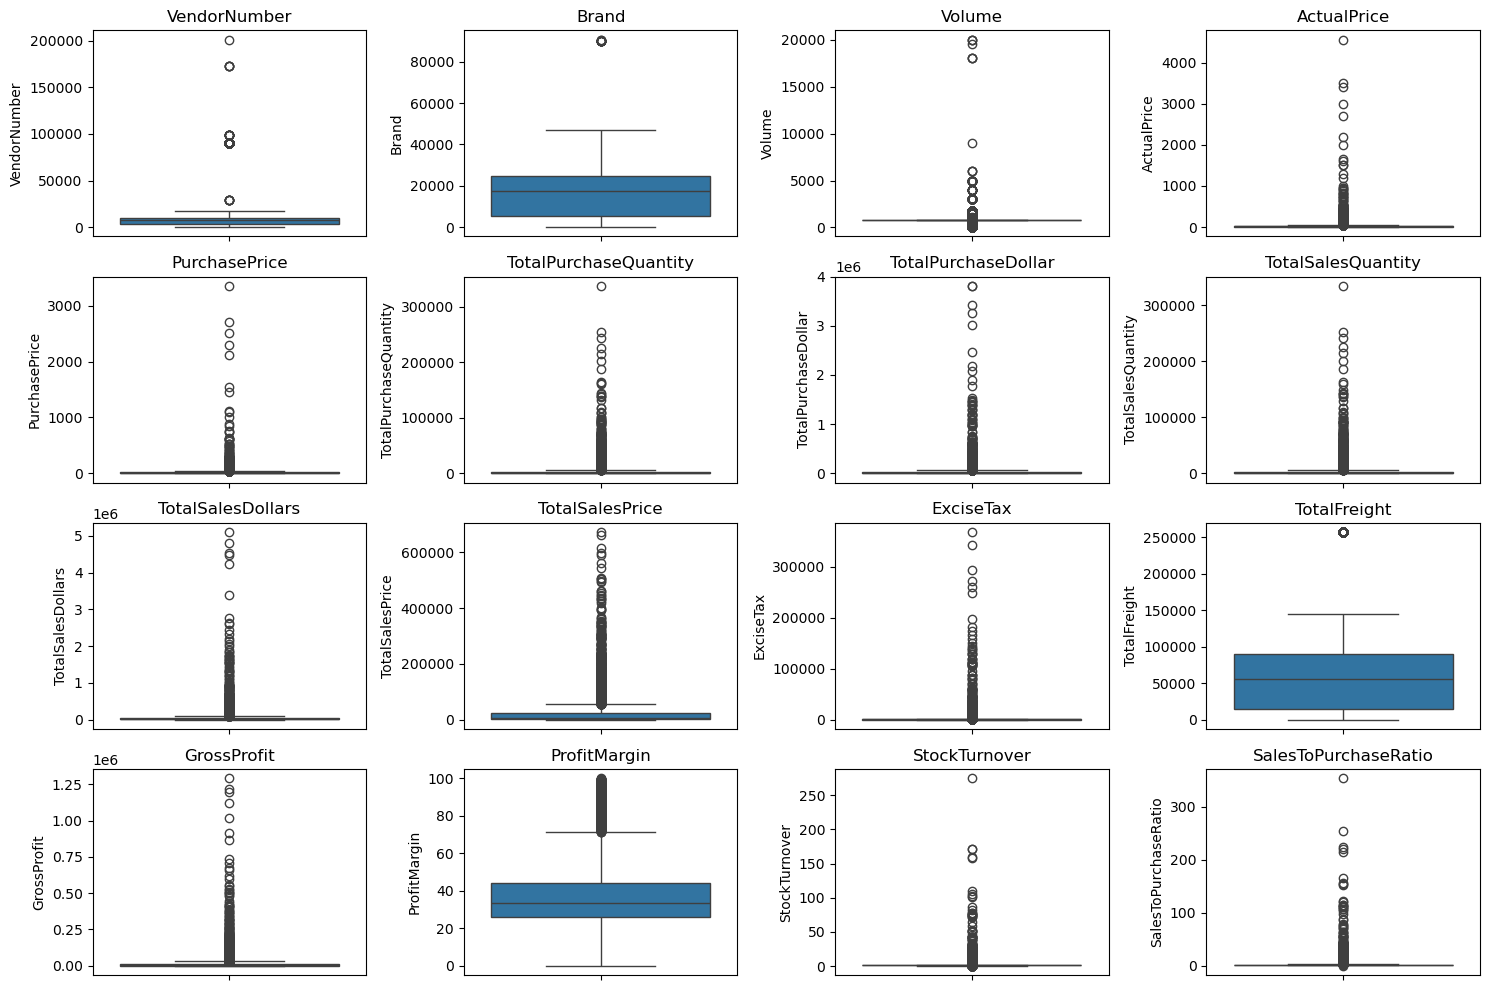

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numeric_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    plt.title(col)
    plt.tight_layout()

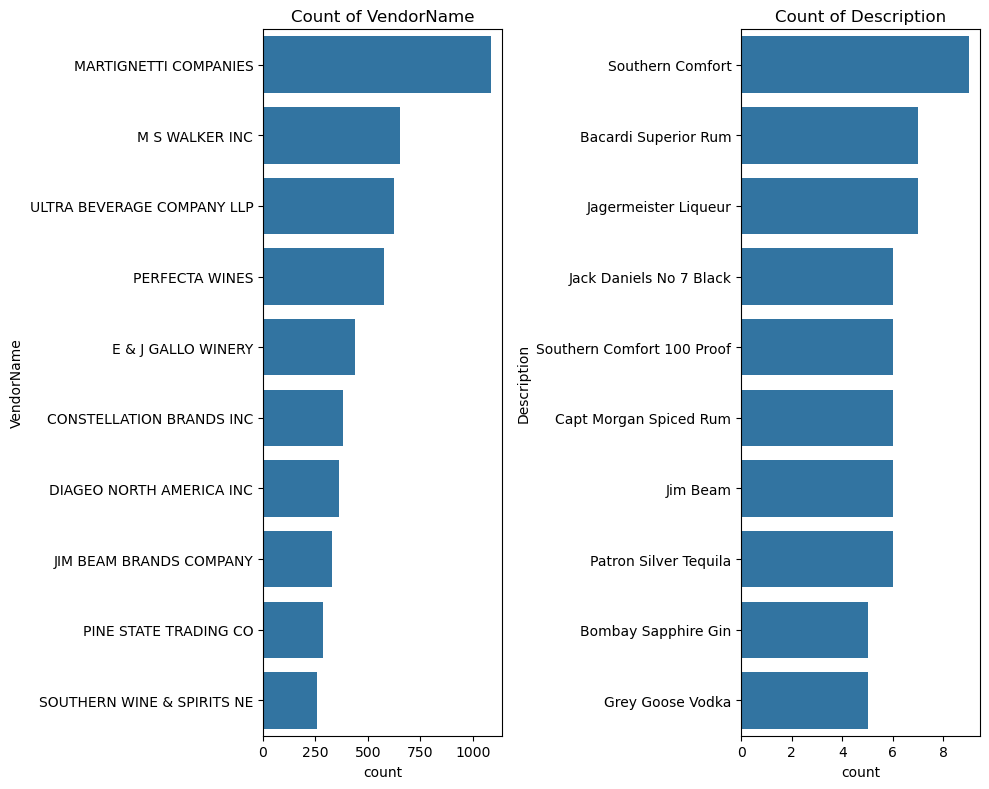

In [10]:
cateogrical_cols = ["VendorName","Description"]
plt.figure(figsize=(10,8))
for i,col in enumerate(cateogrical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"Count of {col}")
    plt.tight_layout()

Text(0.5, 1.0, 'Correlation Heatmap')

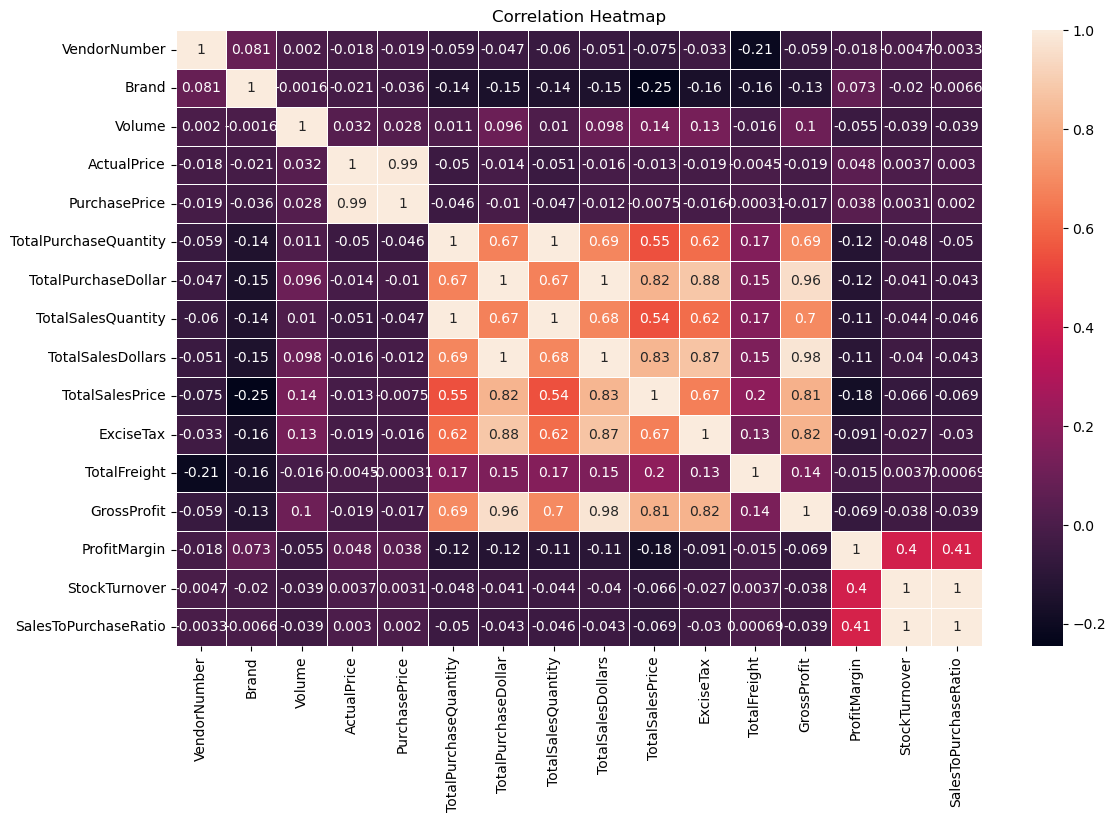

In [11]:
plt.figure(figsize=(13,8))
sns.heatmap(df[numeric_cols].corr(),annot=True,linewidths=0.5)
plt.title("Correlation Heatmap")

# Insights
- Acutal Price has weak relationship with  TotalSalesDollar (-0.016) and GrossProfit(-0.019) means the price donot significantly the sales and gross profit
- When stock turnover increases, profit margin tends to increase too.
- The correlation between stock turnover and total sales dollars (-0.04) indicates a negligible relationship. This suggests that increasing inventory turnover alone does not guarantee higher revenue.
- Strong correlation between the TotalPurchaseQuantity and TotalSalesQuantity which shows efficient inventory turnover

# Analysis
## Identify Brands that needs Promotional or Pricing Adjustements which exhibit lower sales performance but higher profit margins

In [12]:
brand_performance = df.groupby("Description").agg({
    "TotalSalesDollars": "sum",
    "ProfitMargin": "mean"
}).reset_index()
low_threasold = brand_performance["TotalSalesDollars"].quantile(0.15)
high_threasold = brand_performance["ProfitMargin"].quantile(0.85)

In [13]:
targeted_brands = brand_performance[(brand_performance["ProfitMargin"] >high_threasold )  & (brand_performance["TotalSalesDollars"] < low_threasold)]

In [14]:
targeted_brands.sort_values(by="TotalSalesDollars")

,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [15]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] <10000]

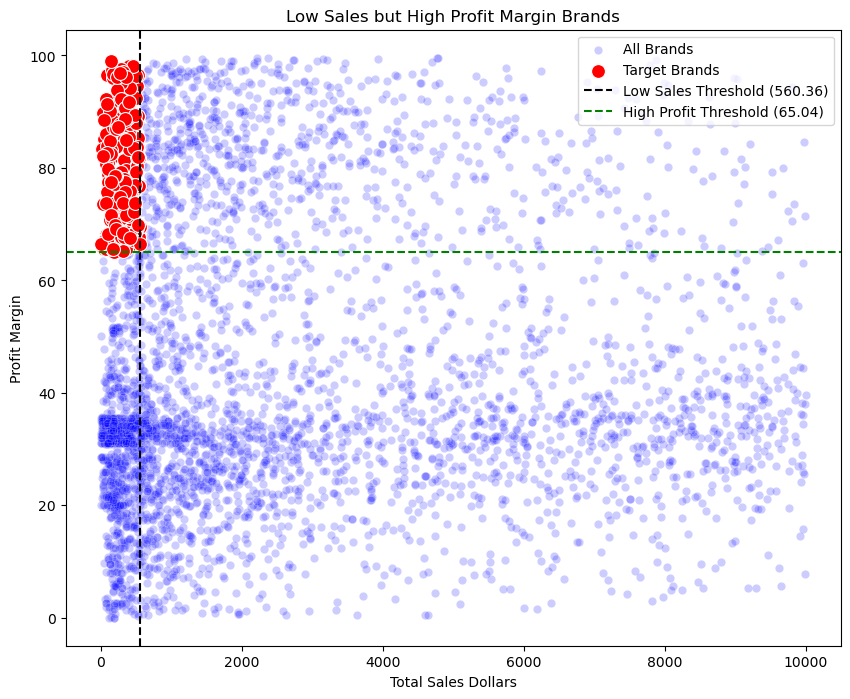

In [16]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=brand_performance,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="blue",
    alpha=0.2,
    label="All Brands"
)

sns.scatterplot(
    data=targeted_brands,
    x="TotalSalesDollars",
    y="ProfitMargin",
    color="red",
    s=100,
    label="Target Brands"
)

plt.axvline(
    x=low_threasold,
    linestyle="--",
    color="black",
    label=f"Low Sales Threshold ({low_threasold:.2f})"
)

plt.axhline(
    y=high_threasold,
    linestyle="--",
    color="green",
    label=f"High Profit Threshold ({high_threasold:.2f})"
)

plt.xlabel("Total Sales Dollars")
plt.ylabel("Profit Margin")
plt.title("Low Sales but High Profit Margin Brands")
plt.legend()
plt.show()

# Which vendor and brands demonstrate the highest sales performance

In [17]:
def human_format(x):
    if x >= 1_000_000:
        return f'{x/1_000_000:.2f}M'
    elif x >= 1_000:
        return f'{x/1_000:.2f}K'
    return f'{x:.0f}'

In [18]:
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors= df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)

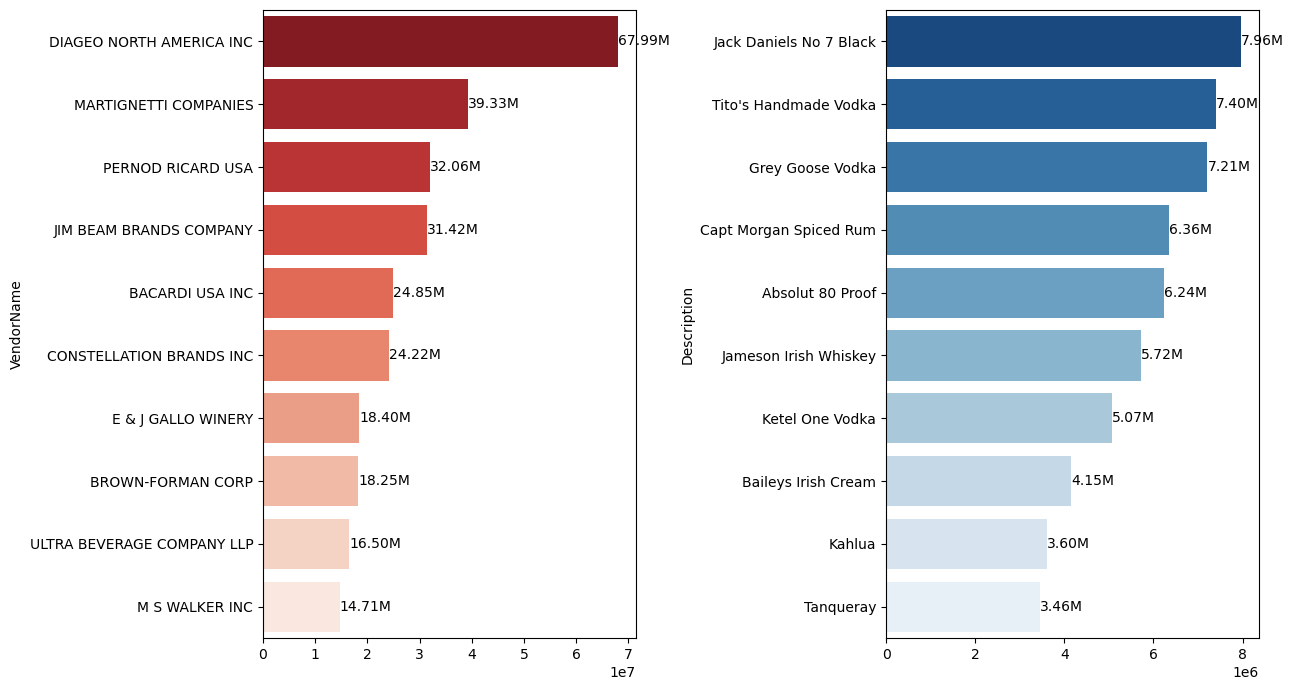

In [19]:
plt.figure(figsize=(13,7))
plt.subplot(1,2,1)

ax = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette="Reds_r"
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.1,   
        bar.get_y() + bar.get_height()/2,
        human_format(bar.get_width()),
        va='center'
    )
plt.subplot(1,2,2)

ax = sns.barplot(
    y=top_brands.index,
    x=top_brands.values,
    palette="Blues_r"
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.1,   # 👈 move slightly right
        bar.get_y() + bar.get_height()/2,
        human_format(bar.get_width()),
        va='center'
    )
plt.tight_layout()
plt.show()



# Which Vendor Contribute to toalPurchase Dollars

In [20]:
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollar": "sum",
    "TotalSalesDollars": "sum",
    "GrossProfit": "sum"
}).reset_index()
vendor_performance["PurchaseContribution%"] = round((vendor_performance["TotalPurchaseDollar"] / vendor_performance["TotalPurchaseDollar"].sum() * 100),2)

In [21]:
vendor_performance = vendor_performance.sort_values(by="PurchaseContribution%",ascending=False)

In [22]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalPurchaseDollar'] = top_vendors["TotalPurchaseDollar"].apply(human_format)
top_vendors['TotalSalesDollars'] = top_vendors["TotalSalesDollars"].apply(human_format)
top_vendors['GrossProfit'] = top_vendors["GrossProfit"].apply(human_format)


In [23]:
top_vendors["Cumulative%"] = top_vendors["PurchaseContribution%"].cumsum()
top_vendors

,VendorName,TotalPurchaseDollar,TotalSalesDollars,GrossProfit,PurchaseContribution%,Cumulative%
25,DIAGEO NORTH AMERICA INC,50.10M,67.99M,17.89M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,39.33M,13.83M,8.30,24.60
68,PERNOD RICARD USA,23.85M,32.06M,8.21M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,31.42M,7.93M,7.64,40.00
6,BACARDI USA INC,17.43M,24.85M,7.42M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,24.22M,8.95M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,18.25M,5.01M,4.31,54.95
30,E & J GALLO WINERY,12.07M,18.40M,6.33M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,16.50M,5.34M,3.63,62.51
53,M S WALKER INC,9.76M,14.71M,4.94M,3.18,65.69


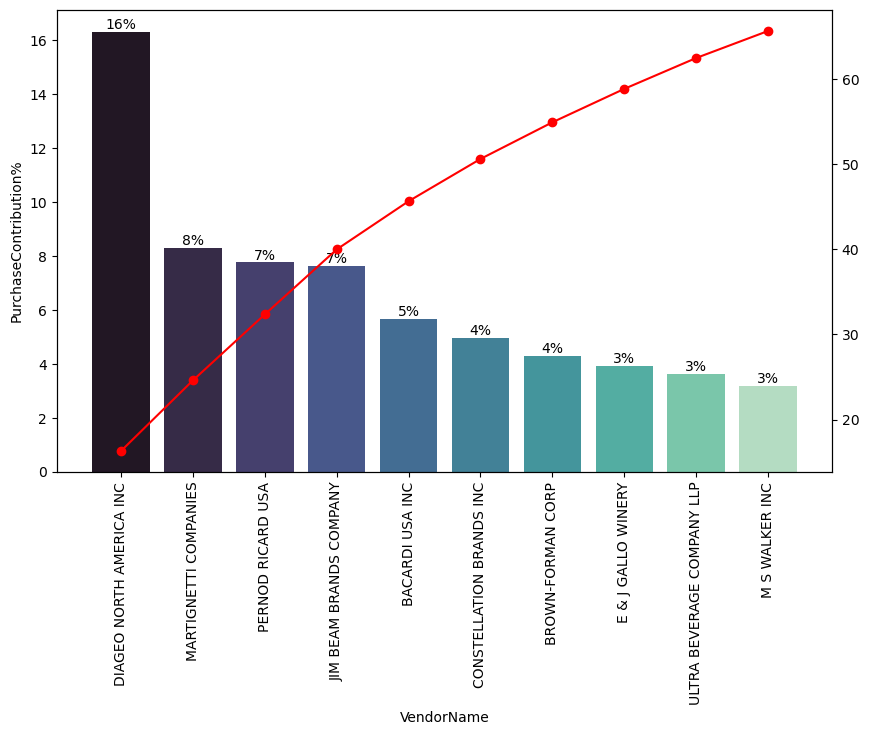

In [24]:
# Pareto Chart
fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(x=top_vendors["VendorName"],y=top_vendors["PurchaseContribution%"],palette='mako',ax=ax1)
for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}%',
        ha='center',
        va='bottom'
    )
plt.xticks(rotation=90)
ax2 = ax1.twinx()
ax2.plot(top_vendors["VendorName"], top_vendors["Cumulative%"], color='red', marker='o')
plt.show()

# How much total Procurement depended on top vendors

In [25]:
print(f"The total Procurement depended on top vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}")

The total Procurement depended on top vendors is 65.69


In [26]:
vendors_names = list(top_vendors['VendorName'].values)
vendors_names.append("Other Vendors")
purchase_contribution = list(top_vendors["PurchaseContribution%"].values)
total_contirbution = sum(purchase_contribution)
remaining_contribution = 100 - total_contirbution
purchase_contribution.append(remaining_contribution)

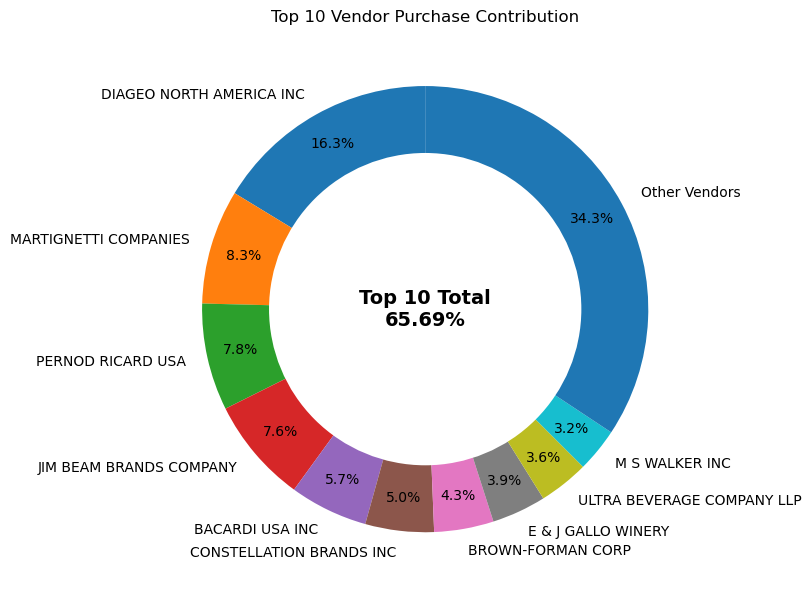

In [27]:
fig, ax = plt.subplots(figsize=(8,8))

ax.pie(
    purchase_contribution,
    labels=vendors_names,
    autopct='%1.1f%%',      # values inside slices
    pctdistance=0.85, 
    startangle=90
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax.add_artist(centre_circle)

ax.text(
    0, 0,
    f"Top 10 Total\n{round(total_contirbution,2)}%",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

plt.title("Top 10 Vendor Purchase Contribution")
plt.tight_layout()
plt.show()

# Does purchasing in bulk reduce the unit price and what is the optimul purchase volume for cost saving

In [28]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["Small","Medium","Large"])

<Axes: xlabel='OrderSize', ylabel='ActualPrice'>

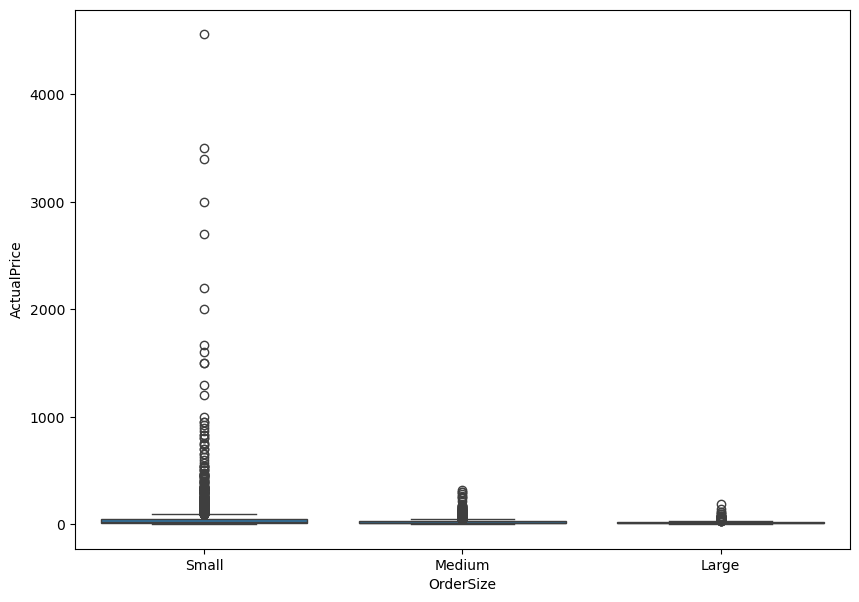

In [29]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df,x="OrderSize",y="ActualPrice")

- The larger the order size, the lower the unit price.
- Buying goods in small order sizes leads to a higher unit price, so vendors should purchase in larger quantities to reduce costs.
- Purchasing goods in larger order sizes reduces the unit price, which ultimately increases profitability.

# Which Vendor have low inventor turnover ,indicating excess stock and slow moving products

In [35]:
df[df["StockTurnover"] <1].groupby("VendorName")["StockTurnover"].mean().sort_values().head(10)

VendorName
ALISA CARR BEVERAGES           0.615385
HIGHLAND WINE MERCHANTS LLC    0.708333
PARK STREET IMPORTS LLC        0.751306
Circa Wines                    0.755676
Dunn Wine Brokers              0.766022
CENTEUR IMPORTS LLC            0.773953
SMOKY QUARTZ DISTILLERY LLC    0.783835
TAMWORTH DISTILLING            0.797078
THE IMPORTED GRAPE LLC         0.807569
WALPOLE MTN VIEW WINERY        0.820548
Name: StockTurnover, dtype: float64

# How much Captial is locked in unsold inventory per vendor , and which vendor contribute most to?

In [37]:
df["UnsoldInventory"] = (df["TotalPurchaseQuantity"]  - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print(f"The Total Unsold Inventory is {human_format(df['UnsoldInventory'].sum())}")

The Total Unsold Inventory is 2.71M


In [44]:
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventory"].sum().reset_index()
top_10_inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventory",ascending=False)
top_10_inventory_value_per_vendor["UnsoldInventory"] = top_10_inventory_value_per_vendor["UnsoldInventory"].apply(human_format)

In [45]:
top_10_inventory_value_per_vendor

,VendorName,UnsoldInventory
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
...,...,...
88,SOUTHERN WINE & SPIRITS NE,-71058
53,M S WALKER INC,-102891
57,MARTIGNETTI COMPANIES,-112538
106,ULTRA BEVERAGE COMPANY LLP,-188478
